# Feature Importance for Tenders and Suppliers

This notebook reproduces the feature-importance workflow in notebook form.
It contains two independent sections:

- tender anomaly feature importance
- supplier anomaly feature importance

Both sections use the same pattern:

1. prepare features exactly as in training code
2. fit `IsolationForest`
3. compute SHAP importance
4. compute permutation importance
5. save charts and summary tables


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

print(f"Project root: {ROOT}")


Project root: C:\Users\Matvii Hotovych\PycharmProjects\Dyplom


In [2]:
NUMERIC_FEATURES = [
    "numberOfBids",
    "numberOfAdmitted",
    "bids_cpv_zscore",
    "admitted_cpv_zscore",
    "admitted_ratio",
    "cpv_deviation",
    "log_value_amount",
    "log_winner_price",
    "log_price_per_unit",
    "log_value_per_day",
    "log_min_bid",
    "price_drop_ratio",
    "tender_duration_days",
    "completion_days",
    "winner_minus_min",
    "complaints",
    "tender_changes",
    "contract_changes",
    "description_missing",
    "winner_price_missing",
    "total_missing_count",
]

SUPPLIER_FEATURES = [
    "num_bids",
    "num_wins",
    "avg_competitors",
    "rejected_bids",
    "complaints",
    "avg_price_per_unit",
    "avg_contract",
    "contract_changes_share",
    "win_rate",
    "log_avg_contract",
    "log_max_contract",
    "log_min_contract",
    "log_avg_price_per_unit",
]

TOP_N = 20
PERM_REPEATS = 10

TENDER_CPV = None
TENDER_DATA_PATH = ROOT / "data" / "raw" / "tender_level_features.csv"
TENDER_OUT_DIR = ROOT / "dump" / "feature_importance" / "tenders"

SUPPLIER_DATA_PATH = ROOT / "data" / "raw" / "supplier_level_features.csv"
SUPPLIER_OUT_DIR = ROOT / "dump" / "feature_importance" / "suppliers"

TENDER_OUT_DIR.mkdir(parents=True, exist_ok=True)
SUPPLIER_OUT_DIR.mkdir(parents=True, exist_ok=True)

def load_tender_data(path):
    return pd.read_csv(path)


def load_supplier_data(path):
    df = pd.read_csv(path)
    if "supplier_id" in df.columns:
        df = df.set_index("supplier_id")
    return df


## Shared utilities

In [3]:
COLORS = {
    "top3": "#c0392b",
    "top10": "#e67e22",
    "rest": "#9ecae1",
    "base": "#2980b9",
    "anomaly": "#c0392b",
}


def fit_iforest(X_scaled, n_estimators=1000):
    iso = IsolationForest(
        n_estimators=n_estimators,
        contamination="auto",
        random_state=42,
        n_jobs=-1,
    )
    iso.fit(X_scaled)
    raw_scores = -iso.score_samples(X_scaled)
    labels = iso.predict(X_scaled)
    score_z = zscore(raw_scores)
    return iso, raw_scores, score_z, labels


def compute_shap_importance(iso, X_scaled):
    explainer = shap.TreeExplainer(iso)
    shap_values = explainer.shap_values(X_scaled)
    shap_df = pd.DataFrame(
        {
            "feature": X_scaled.columns,
            "shap_importance": np.abs(shap_values).mean(axis=0),
        }
    ).sort_values("shap_importance", ascending=False).reset_index(drop=True)
    return shap_values, shap_df


def compute_permutation_importance(iso, X_scaled, n_repeats=10):
    baseline = -iso.score_samples(X_scaled).mean()
    rows = []

    for feature in X_scaled.columns:
        deltas = []
        for _ in range(n_repeats):
            X_perm = X_scaled.copy()
            X_perm[feature] = X_perm[feature].sample(frac=1, random_state=None).values
            permuted = -iso.score_samples(X_perm).mean()
            deltas.append(permuted - baseline)
        rows.append(
            {
                "feature": feature,
                "perm_importance_mean": float(np.mean(deltas)),
                "perm_importance_std": float(np.std(deltas)),
            }
        )

    return pd.DataFrame(rows).sort_values(
        "perm_importance_mean", ascending=False
    ).reset_index(drop=True)


def importance_summary(shap_df, perm_df):
    summary = shap_df.merge(
        perm_df[["feature", "perm_importance_mean", "perm_importance_std"]],
        on="feature",
        how="left",
    )
    summary["shap_rank"] = summary["shap_importance"].rank(ascending=False).astype(int)
    summary["perm_rank"] = summary["perm_importance_mean"].rank(ascending=False).astype(int)
    summary["avg_rank"] = ((summary["shap_rank"] + summary["perm_rank"]) / 2).round(1)
    return summary.sort_values("avg_rank").reset_index(drop=True)


def _bar_colors(n_total, top3=3, top10=10):
    return [
        COLORS["top3"] if i < top3 else COLORS["top10"] if i < top10 else COLORS["rest"]
        for i in range(n_total)
    ]


def plot_shap_bar(shap_df, title, out_path, top_n=20):
    top = shap_df.head(top_n)
    colors = _bar_colors(len(top))

    fig, ax = plt.subplots(figsize=(10, top_n * 0.42 + 1.5))
    ax.barh(top["feature"][::-1], top["shap_importance"][::-1], color=colors[::-1])
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(title)
    ax.legend(
        handles=[
            mpatches.Patch(color=COLORS["top3"], label="Top 3"),
            mpatches.Patch(color=COLORS["top10"], label="Top 4-10"),
            mpatches.Patch(color=COLORS["rest"], label="Rest"),
        ],
        fontsize=9,
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_shap_beeswarm(shap_values, X_scaled, title, out_path, top_n=20):
    plt.figure(figsize=(10, top_n * 0.42 + 1.5))
    shap.summary_plot(
        shap_values,
        X_scaled,
        max_display=top_n,
        show=False,
        color_bar_label="Scaled feature value",
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_permutation_bar(perm_df, title, out_path, top_n=20):
    top = perm_df.head(top_n)
    fig, ax = plt.subplots(figsize=(10, top_n * 0.42 + 1.5))
    ax.barh(
        top["feature"][::-1],
        top["perm_importance_mean"][::-1],
        xerr=top["perm_importance_std"][::-1],
        color=COLORS["base"],
        alpha=0.85,
        capsize=3,
    )
    ax.set_xlabel("Change in mean anomaly score after permutation")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_feature_distributions(X_raw, labels, features, title, out_path, top_n=20, n_cols=3):
    selected = [f for f in features if f in X_raw.columns][:top_n]
    n_rows = int(np.ceil(len(selected) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3.2))
    axes = np.atleast_1d(axes).flatten()

    for i, feature in enumerate(selected):
        normal = X_raw.loc[labels == 1, feature].dropna()
        anomaly = X_raw.loc[labels == -1, feature].dropna()
        axes[i].hist(normal, bins=40, alpha=0.55, color=COLORS["base"], density=True, label="Normal")
        axes[i].hist(anomaly, bins=40, alpha=0.55, color=COLORS["anomaly"], density=True, label="Anomaly")
        axes[i].set_title(feature, fontsize=9)
        axes[i].legend(fontsize=7)

    for j in range(len(selected), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


## Tender feature importance

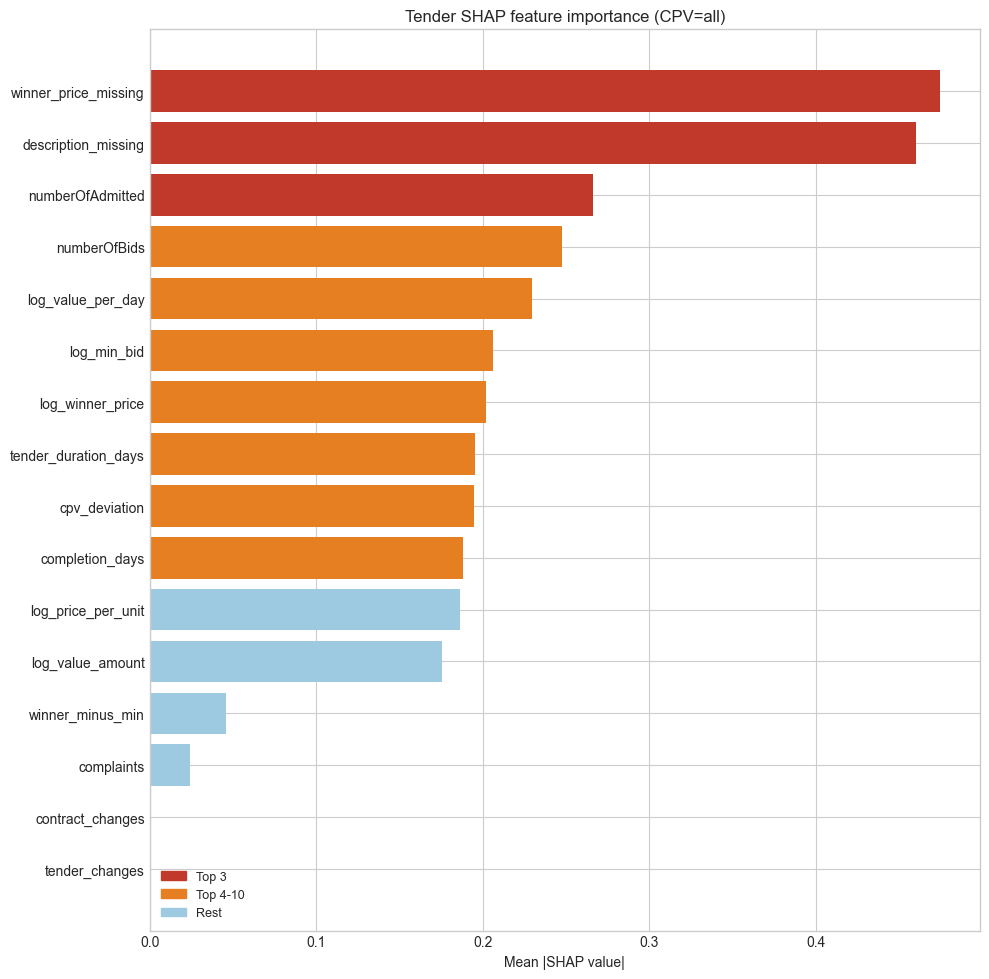

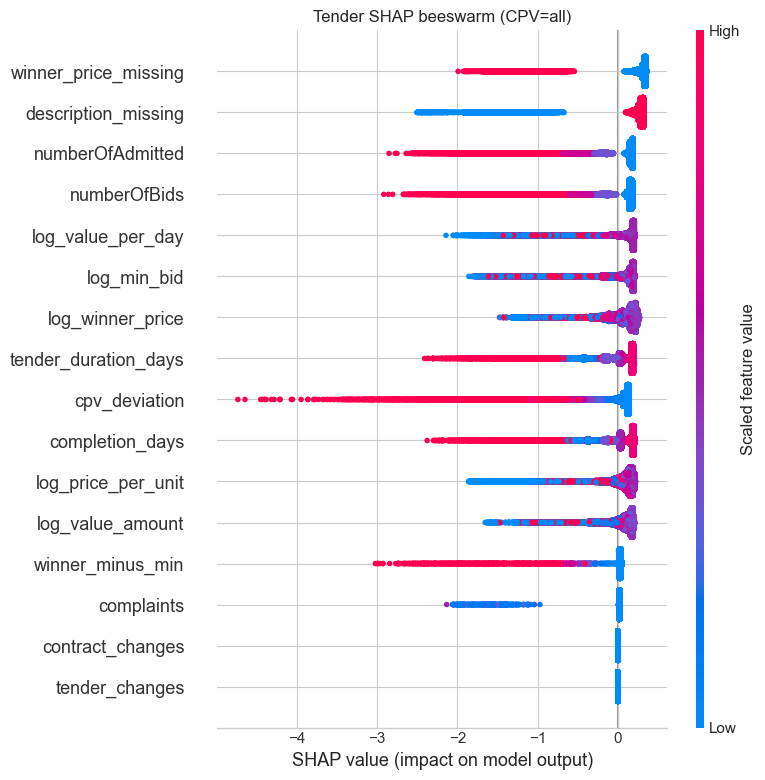

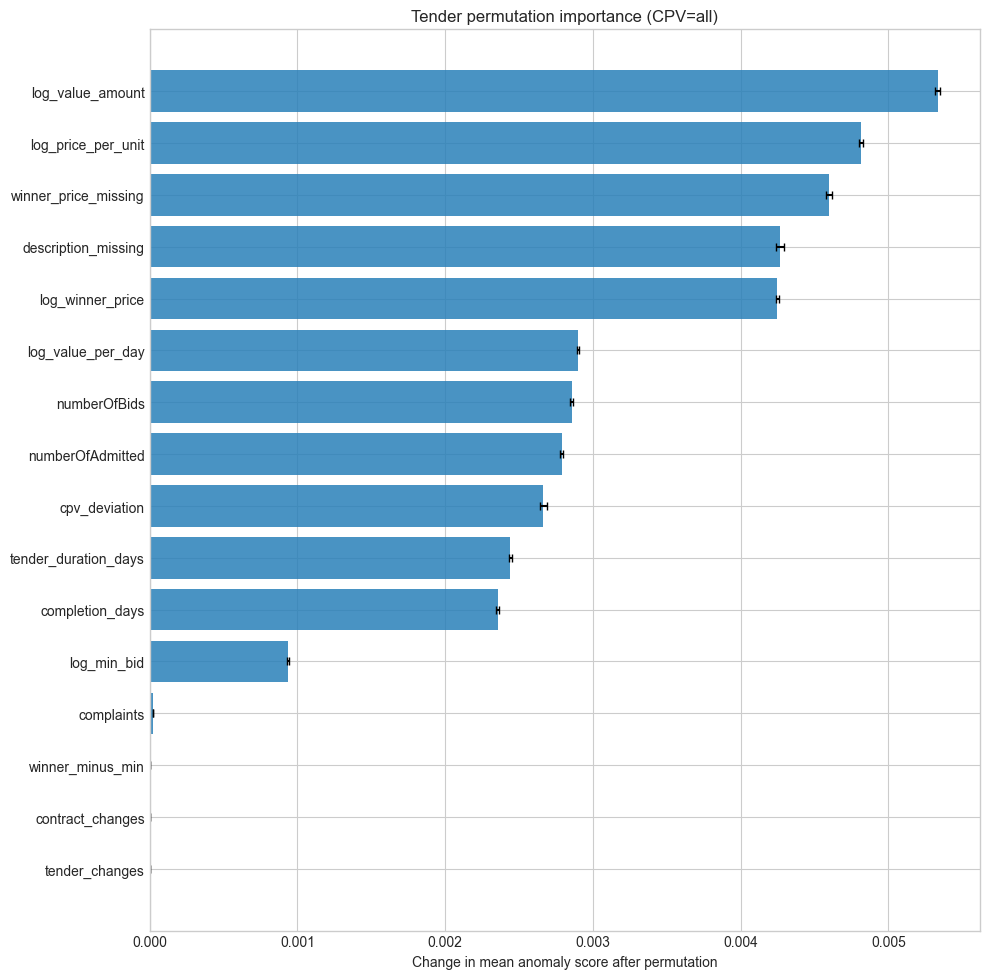

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

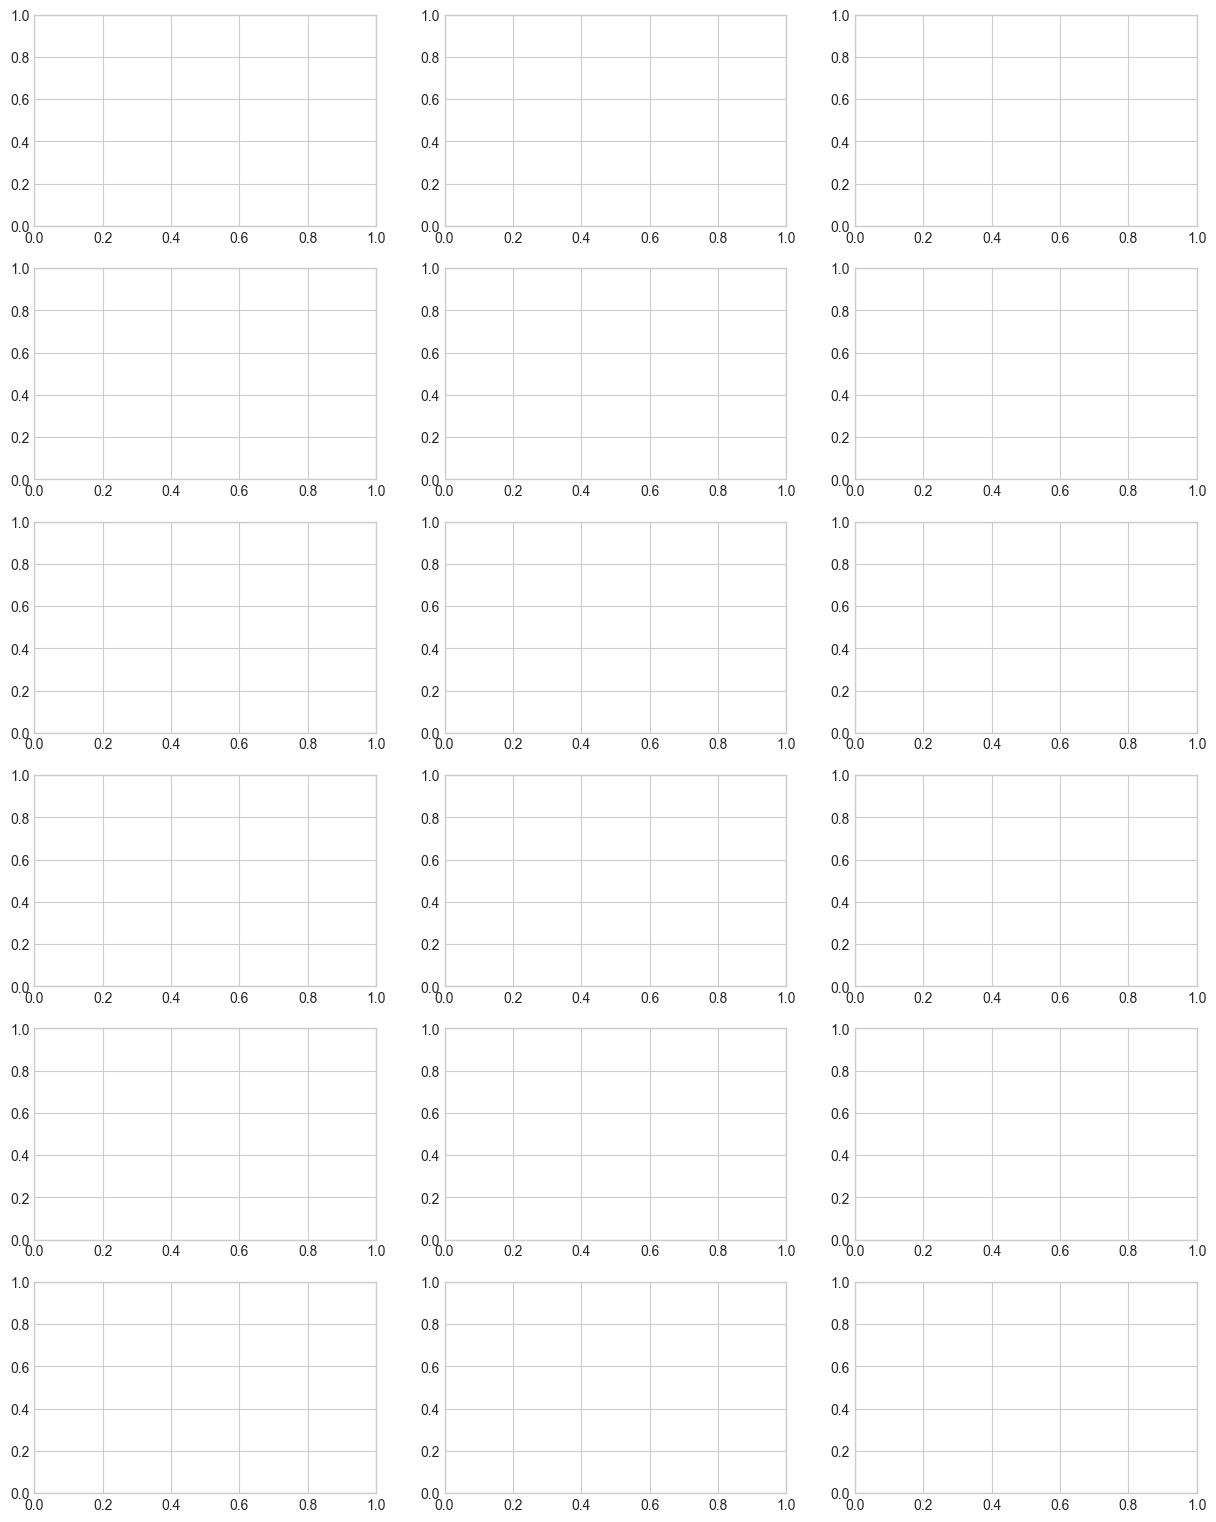

In [4]:
def prepare_tenders(path, cpv=None):
    df = load_tender_data(str(path))
    if cpv is not None:
        df = df[df["cpv"].astype(str).str.startswith(str(cpv))].copy()

    available = [feature for feature in NUMERIC_FEATURES if feature in df.columns]
    X_raw = df[available].copy()

    imputer = SimpleImputer(strategy="median")
    scaler = RobustScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(imputer.fit_transform(X_raw)),
        columns=available,
        index=df.index,
    )
    return df, X_raw, X_scaled


tender_df, tender_X_raw, tender_X_scaled = prepare_tenders(TENDER_DATA_PATH, TENDER_CPV)
tender_iso, tender_raw_scores, tender_score_z, tender_labels = fit_iforest(tender_X_scaled, n_estimators=1000)
tender_shap_values, tender_shap_df = compute_shap_importance(tender_iso, tender_X_scaled)
tender_perm_df = compute_permutation_importance(tender_iso, tender_X_scaled, n_repeats=PERM_REPEATS)
tender_summary = importance_summary(tender_shap_df, tender_perm_df)

plot_shap_bar(
    tender_shap_df,
    title=f"Tender SHAP feature importance (CPV={TENDER_CPV or 'all'})",
    out_path=TENDER_OUT_DIR / "tender_shap_bar.png",
    top_n=TOP_N,
)
plot_shap_beeswarm(
    tender_shap_values,
    tender_X_scaled,
    title=f"Tender SHAP beeswarm (CPV={TENDER_CPV or 'all'})",
    out_path=TENDER_OUT_DIR / "tender_shap_beeswarm.png",
    top_n=TOP_N,
)
plot_permutation_bar(
    tender_perm_df,
    title=f"Tender permutation importance (CPV={TENDER_CPV or 'all'})",
    out_path=TENDER_OUT_DIR / "tender_perm_bar.png",
    top_n=TOP_N,
)
plot_feature_distributions(
    tender_X_raw,
    tender_labels,
    tender_shap_df["feature"].tolist(),
    title=f"Tender feature distributions (CPV={TENDER_CPV or 'all'})",
    out_path=TENDER_OUT_DIR / "tender_distributions.png",
    top_n=TOP_N,
)

tender_summary.to_csv(TENDER_OUT_DIR / "tender_feature_importance_summary.csv", index=False)
tender_summary.head(TOP_N)


## Supplier feature importance

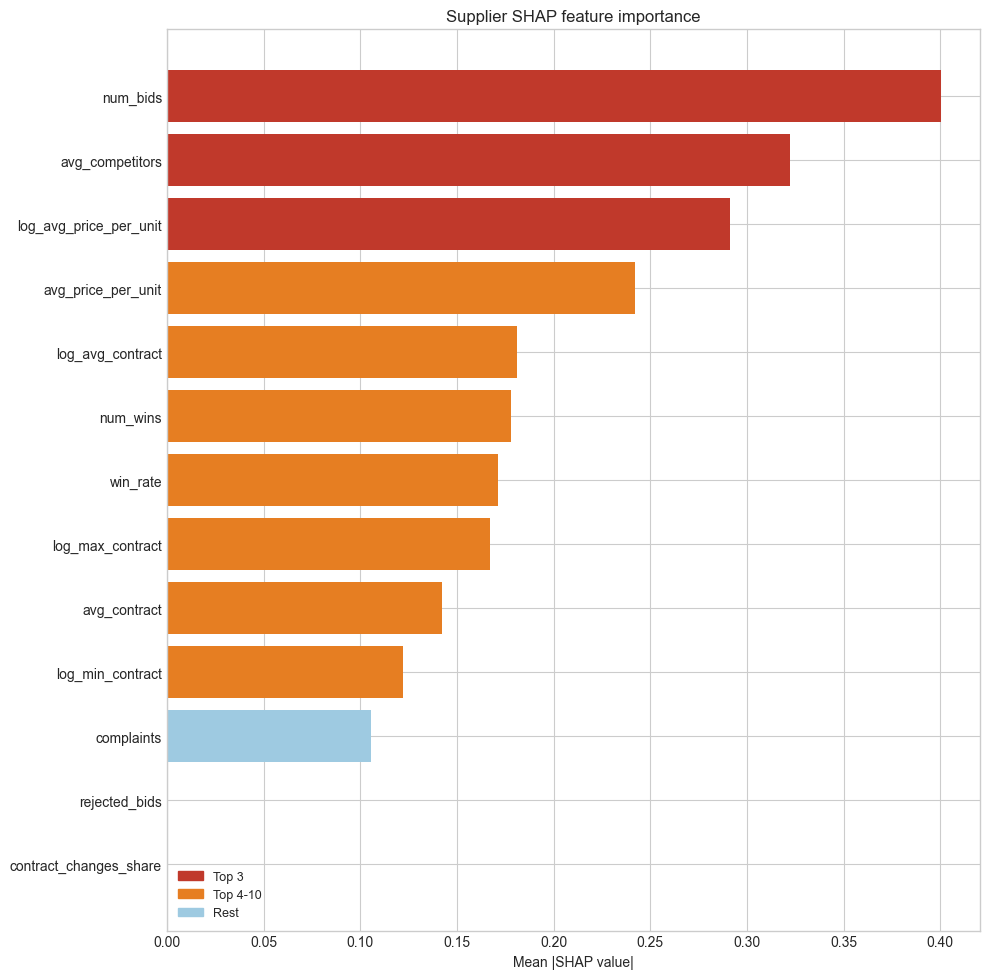

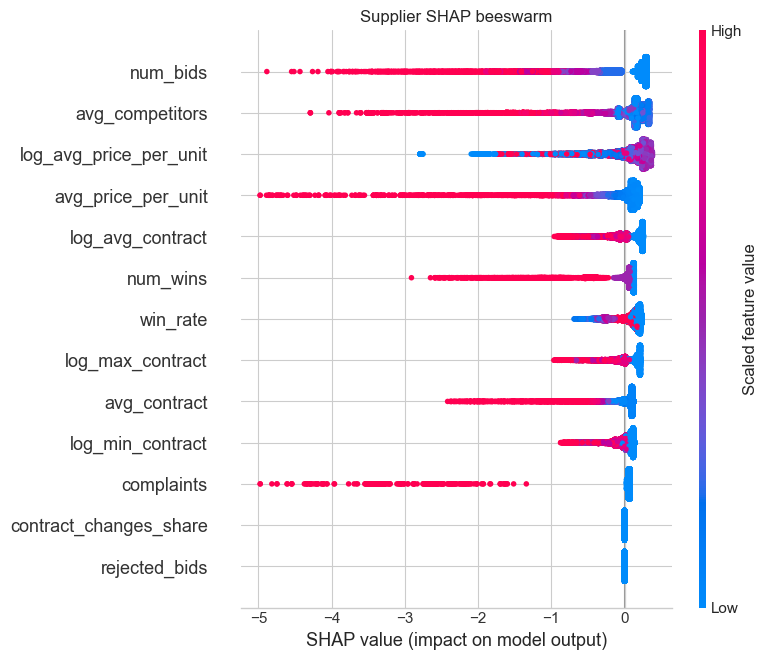

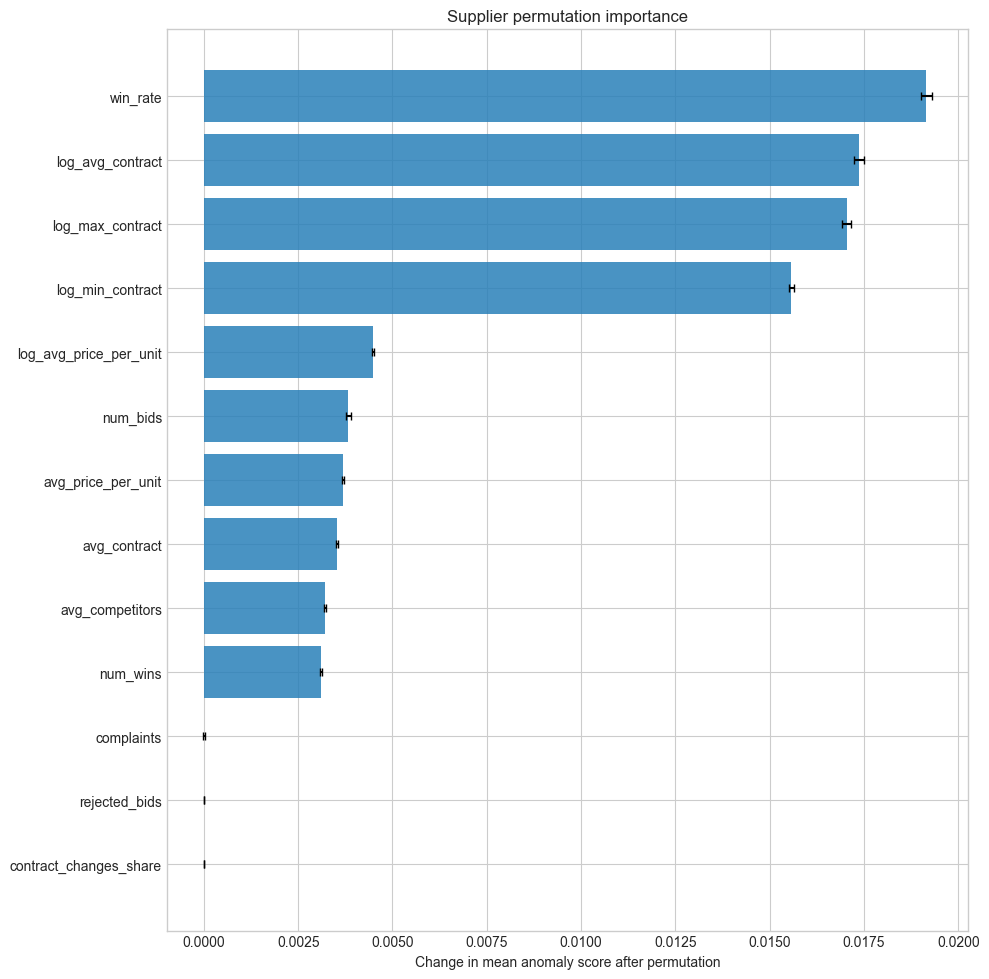

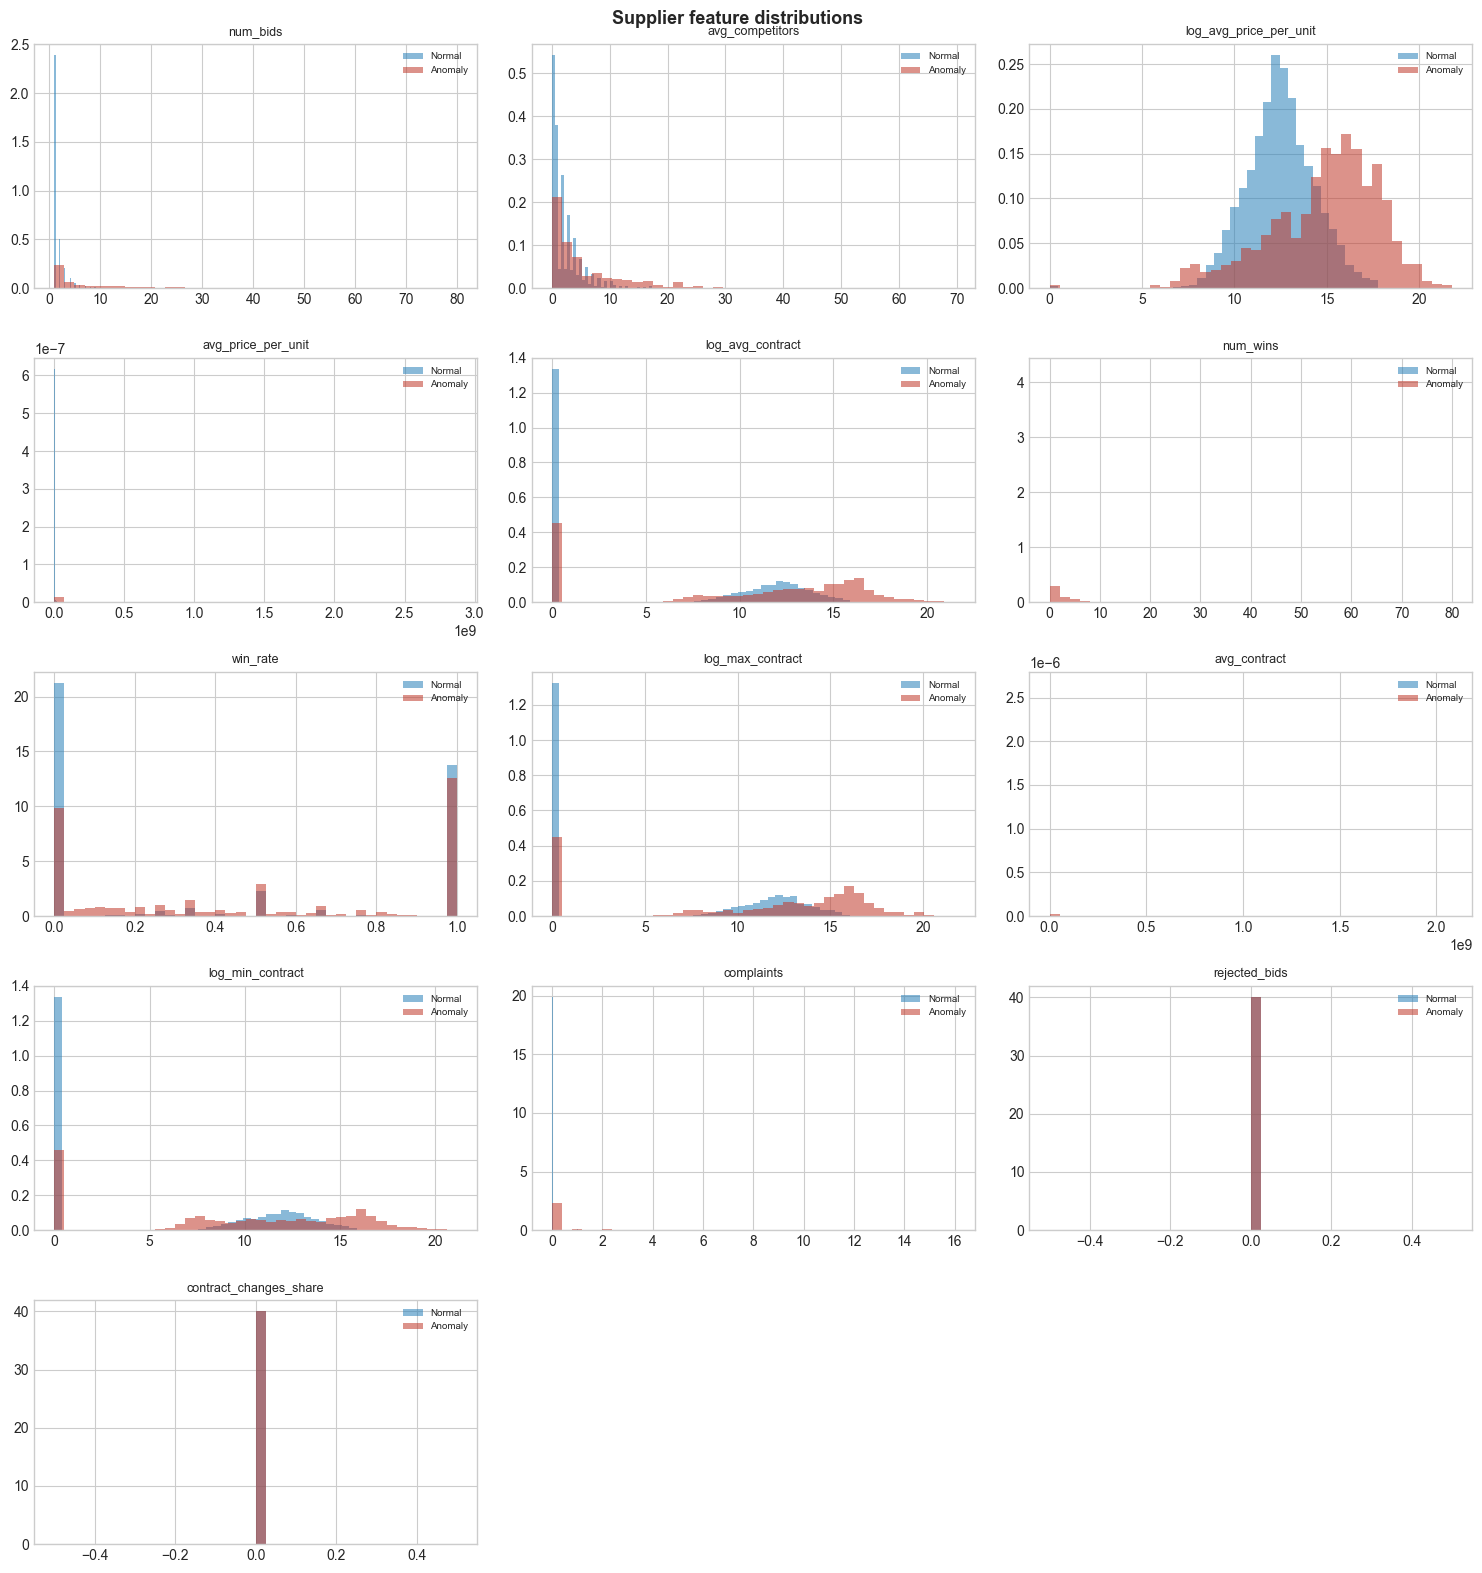

,feature,shap_importance,perm_importance_mean,perm_importance_std,shap_rank,perm_rank,avg_rank
0,num_bids,0.400523,0.003833,0.000074,1,6,3.5
1,log_avg_contract,0.180816,0.017366,0.000129,5,2,3.5
2,win_rate,0.171209,0.019154,0.000146,7,1,4.0
3,log_avg_price_per_unit,0.291014,0.004484,0.000028,3,5,4.0
4,avg_price_per_unit,0.241934,0.003690,0.000026,4,7,5.5
5,avg_competitors,0.322359,0.003213,0.000028,2,9,5.5
6,log_max_contract,0.166930,0.017036,0.000114,8,3,5.5
7,log_min_contract,0.121942,0.015576,0.000062,10,4,7.0
8,num_wins,0.177868,0.003103,0.000034,6,10,8.0
9,avg_contract,0.142014,0.003526,0.000034,9,8,8.5


In [5]:
def prepare_suppliers(path):
    df = load_supplier_data(str(path)).reset_index()
    available = [feature for feature in SUPPLIER_FEATURES if feature in df.columns]
    X_raw = df[available].copy()

    imputer = SimpleImputer(strategy="median")
    scaler = RobustScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(imputer.fit_transform(X_raw)),
        columns=available,
        index=df.index,
    )
    return df, X_raw, X_scaled


supplier_df, supplier_X_raw, supplier_X_scaled = prepare_suppliers(SUPPLIER_DATA_PATH)
supplier_iso, supplier_raw_scores, supplier_score_z, supplier_labels = fit_iforest(
    supplier_X_scaled,
    n_estimators=500,
)
supplier_shap_values, supplier_shap_df = compute_shap_importance(supplier_iso, supplier_X_scaled)
supplier_perm_df = compute_permutation_importance(
    supplier_iso,
    supplier_X_scaled,
    n_repeats=PERM_REPEATS,
)
supplier_summary = importance_summary(supplier_shap_df, supplier_perm_df)

plot_shap_bar(
    supplier_shap_df,
    title="Supplier SHAP feature importance",
    out_path=SUPPLIER_OUT_DIR / "supplier_shap_bar.png",
    top_n=TOP_N,
)
plot_shap_beeswarm(
    supplier_shap_values,
    supplier_X_scaled,
    title="Supplier SHAP beeswarm",
    out_path=SUPPLIER_OUT_DIR / "supplier_shap_beeswarm.png",
    top_n=TOP_N,
)
plot_permutation_bar(
    supplier_perm_df,
    title="Supplier permutation importance",
    out_path=SUPPLIER_OUT_DIR / "supplier_perm_bar.png",
    top_n=TOP_N,
)
plot_feature_distributions(
    supplier_X_raw,
    supplier_labels,
    supplier_shap_df["feature"].tolist(),
    title="Supplier feature distributions",
    out_path=SUPPLIER_OUT_DIR / "supplier_distributions.png",
    top_n=TOP_N,
)

supplier_summary.to_csv(SUPPLIER_OUT_DIR / "supplier_feature_importance_summary.csv", index=False)
supplier_summary.head(TOP_N)
